<a href="https://colab.research.google.com/github/cmburban/MAT-422/blob/main/MAT422_Section_2_2_Probability_Random_Variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 2.2: Probability and Random Variables

Topics: Probability axioms, Conditional probability, Discrete random variables, Continuous random variables

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 2.2.1 Probability Axioms

Probability describes how likely an event is to happen. The basic probability rules say that probabilities cannot be negative, the probability of all possible outcomes is 1, and probabilities can be added for events that are combined.

I will use a simple dice example to check these rules with Python.

In [11]:
outcomes = np.array([1, 2, 3, 4, 5, 6])
probabilities = np.ones(6) / 6

# Event A: rolling an even number
event_a = outcomes % 2 == 0

# Event B: rolling a number greater than 4
event_b = outcomes > 4

print("Probabilities nonnegative:", np.all(probabilities >= 0))
print("Total probability:", probabilities.sum())

p_a = probabilities[event_a].sum()
p_b = probabilities[event_b].sum()
p_intersection = probabilities[event_a & event_b].sum()
p_union = probabilities[event_a | event_b].sum()

print("P(A: even) =", p_a)
print("P(B: greater than 4) =", p_b)
print("P(A and B) =", p_intersection)
print("P(A or B) =", p_union)

print("P(A) + P(B) - P(A and B) =",
      p_a + p_b - p_intersection)

Probabilities nonnegative: True
Total probability: 0.9999999999999999
P(A: even) = 0.5
P(B: greater than 4) = 0.3333333333333333
P(A and B) = 0.16666666666666666
P(A or B) = 0.6666666666666666
P(A) + P(B) - P(A and B) = 0.6666666666666666


The probabilities are all nonnegative, and the total probability is 1, which follows the basic probability rules. The last two results also show the addition rule for the union of two events. In this example, event A is rolling an even number and event B is rolling a number greater than 4.

## 2.2.2 Conditional Probability

Conditional probability measures the probability of an event when we already know that another event has happened. It is written as P(A | B), which means the probability of A given B.

I will use the same six-sided die idea from the previous example. This time, I will find the probability of rolling an even number given that the roll is greater than 3.

In [12]:
outcomes = np.array([1, 2, 3, 4, 5, 6])

# Event A: rolling an even number
event_a = outcomes % 2 == 0

# Event B: rolling a number greater than 3
event_b = outcomes > 3

p_a_and_b = np.mean(event_a & event_b)
p_b = np.mean(event_b)

conditional_probability = p_a_and_b / p_b

print("P(A and B) =", p_a_and_b)
print("P(B) =", p_b)
print("P(A | B) =", conditional_probability)

P(A and B) = 0.3333333333333333
P(B) = 0.5
P(A | B) = 0.6666666666666666


The conditional probability is about 0.667, or 66.7%. This makes sense because once I know the roll is greater than 3, the possible outcomes are only 4, 5, and 6. Two of those three outcomes are even, so the probability of an even number given this condition is 2/3.

## 2.2.3 Discrete Random Variables

A discrete random variable has a countable set of possible values. Each value has a probability, and all of the probabilities must add up to 1.

I will use the number of heads when flipping a coin three times. The possible values are 0, 1, 2, or 3 heads.

In [13]:
# Possible numbers of heads in 3 coin flips
x = np.array([0, 1, 2, 3])

# Probabilities for each possible value
probabilities = np.array([1, 3, 3, 1]) / 8

print("Possible values:", x)
print("Probabilities:", probabilities)

print("\nSum of probabilities:", probabilities.sum())

# Expected value
expected_value = np.sum(x * probabilities)

print("Expected value:", expected_value)

Possible values: [0 1 2 3]
Probabilities: [0.125 0.375 0.375 0.125]

Sum of probabilities: 1.0
Expected value: 1.5


### Visualizing the Probability Distribution

A bar chart makes it easier to see how the probabilities are distributed across the possible values of the random variable. In this example, getting 1 or 2 heads is more likely than getting 0 or 3 heads.

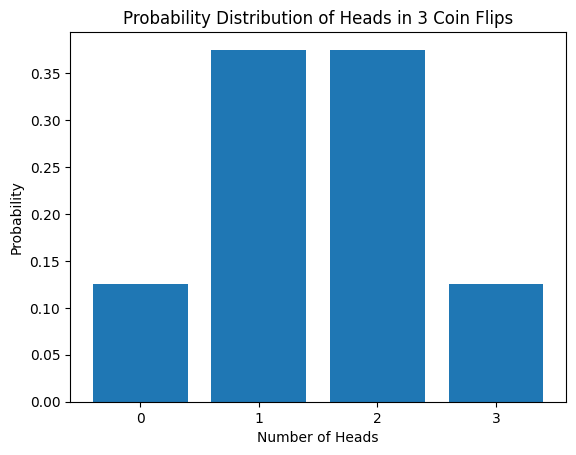

In [14]:
plt.bar(x, probabilities)

plt.xlabel("Number of Heads")
plt.ylabel("Probability")
plt.title("Probability Distribution of Heads in 3 Coin Flips")
plt.xticks(x)

plt.show()

The graph shows that 1 and 2 heads have the highest probabilities. Getting either 0 or 3 heads is less likely. The probabilities of all possible outcomes add up to 1, which confirms that this is a valid probability distribution.

## 2.2.4 Continuous Random Variables

A continuous random variable can take any value within an interval. Instead of assigning a separate probability to each individual value, we use a probability density function to describe how the probability is distributed.

I will use a uniform distribution between 0 and 10. This means every value in this interval has the same density, and the total area under the density curve is 1.

In [15]:
# Values from 0 to 10
x_continuous = np.linspace(0, 10, 500)

# Uniform probability density on [0, 10]
density = np.ones_like(x_continuous) / 10

print("Density value:", density[0])
print("Approximate interval length:", x_continuous[-1] - x_continuous[0])

# Probability of being between 2 and 6
lower = 2
upper = 6

probability_interval = (upper - lower) / 10

print("P(2 <= X <= 6) =", probability_interval)

Density value: 0.1
Approximate interval length: 10.0
P(2 <= X <= 6) = 0.4


### Visualizing the Continuous Distribution

The graph shows the probability density across the interval from 0 to 10. For a uniform distribution, the density is constant. The probability of an interval is represented by the area under the density curve over that interval.

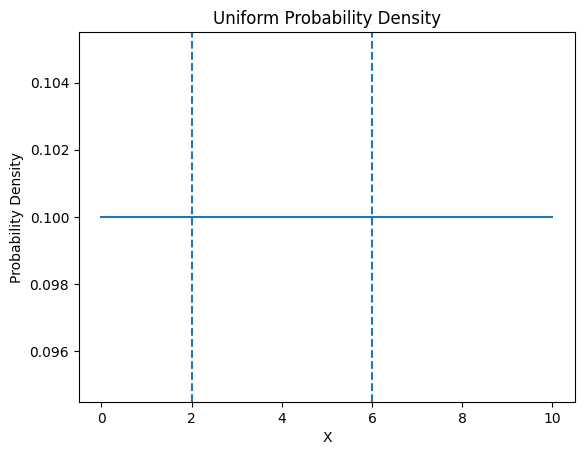

In [16]:
plt.plot(x_continuous, density)

plt.xlabel("X")
plt.ylabel("Probability Density")
plt.title("Uniform Probability Density")

plt.axvline(lower, linestyle="--")
plt.axvline(upper, linestyle="--")

plt.show()

The graph shows a constant probability density between 0 and 10. The probability of a value falling between 2 and 6 is 0.4 because that interval covers 40% of the total range. This also shows why continuous probabilities are found over intervals rather than by assigning probability to individual points.

## End of Notebook Reflection

This week I learned how probability can be used to describe the likelihood of different events. The probability axioms showed me the basic rules that probabilities must follow, such as having a total probability of 1. I also learned how conditional probability can change the probability of an event when additional information is known.

I learned that discrete random variables have a countable set of possible values, and each value can have its own probability. The coin-flip example also showed how the expected value can describe the average result over many trials.

Finally, I learned that continuous random variables can take values across an interval. Instead of finding the probability of one specific value, probabilities are found over intervals using the area under a probability density. Overall, these examples helped me see how different probability concepts can be represented using both mathematics and Python.

## Reference

[Mathematical Methods in Data Science - Elsevier (2023)](https://doi.org/10.1016/B978-0-44-318679-0.00007-7)

[Numpy - Singular Value Decomposition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)

[Matplotlib](https://matplotlib.org/stable/)

[OpenAI - ChatGPT (2026)](https://chatgpt.com)

## Checklist

I explained each concept in words before or after the code. [DONE]

I verified important claims numerically, such as dot products, norms, identities, or residuals. [DONE]

I changed or extended at least one example so the notebook reflects my own work. [DONE]

I ran the notebook from top to bottom without errors. [DONE]

I saved the notebook from Google Colab directly to GitHub, following the course instructions. [DONE]